In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [6]:
df = pd.read_csv("data/Unemployment in India.csv")


In [7]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


## Dataset Preview

The first five rows of the dataset are displayed to understand the structure and columns.

In [8]:
df.shape

(768, 7)

## Dataset Shape

This shows the total number of rows and columns in the dataset.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


## Dataset Information

The dataset information shows column names, data types, and non-null values.

In [10]:
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

## Missing Values

Checking for missing values before performing data analysis.

In [11]:
df = df.dropna()

In [12]:
df.isnull().sum()

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Area                                        0
dtype: int64

In [13]:
df.columns = df.columns.str.strip()

In [14]:
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [15]:
df["Date"] = pd.to_datetime(df["Date"])

C:\Users\ELCOT\AppData\Local\Temp\ipykernel_1608\936118274.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"])


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB


In [17]:
region_avg = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values()
region_avg

Region
Meghalaya            4.798889
Odisha               5.657857
Assam                6.428077
Uttarakhand          6.582963
Gujarat              6.663929
Karnataka            6.676071
Sikkim               7.249412
Madhya Pradesh       7.406429
Andhra Pradesh       7.477143
Maharashtra          7.557500
Telangana            7.737857
West Bengal          8.124643
Chhattisgarh         9.240357
Goa                  9.274167
Tamil Nadu           9.284286
Kerala              10.123929
Puducherry          10.215000
Punjab              12.031071
Uttar Pradesh       12.551429
Rajasthan           14.058214
Chandigarh          15.991667
Jammu & Kashmir     16.188571
Delhi               16.495357
Himachal Pradesh    18.540357
Bihar               18.918214
Jharkhand           20.585000
Haryana             26.283214
Tripura             28.350357
Name: Estimated Unemployment Rate (%), dtype: float64

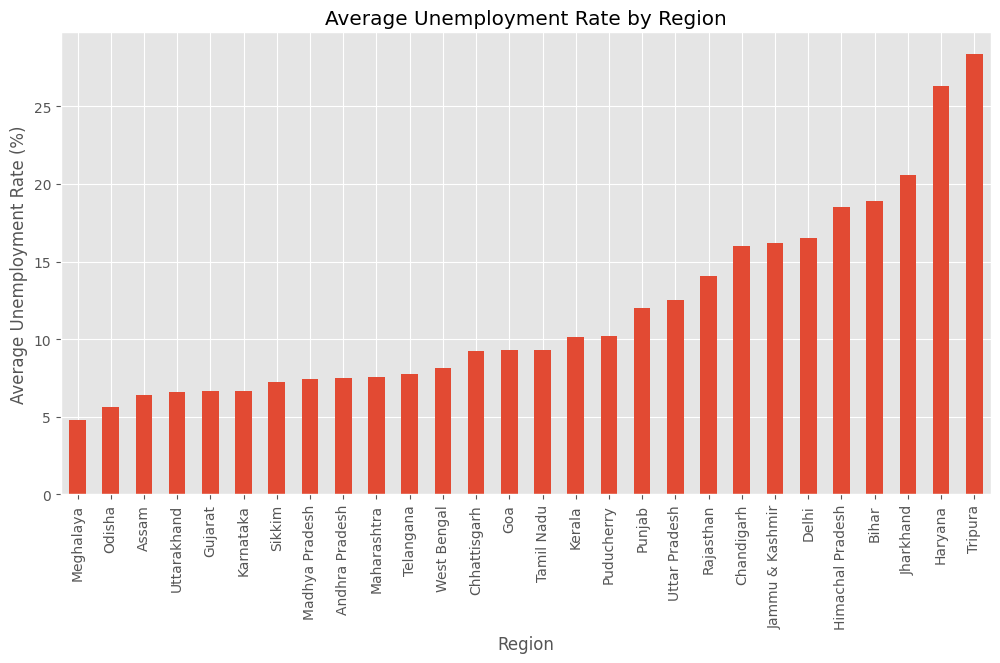

In [18]:
plt.figure(figsize=(12,6))

region_avg.plot(kind="bar")

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=90)

plt.show()

## Observation

- Unemployment rates vary across different regions.
- Some regions have consistently higher unemployment than others.
- This indicates regional differences in employment opportunities.

In [19]:
df["Month"] = df["Date"].dt.month_name()

In [20]:
month_avg = df.groupby("Month")["Estimated Unemployment Rate (%)"].mean()

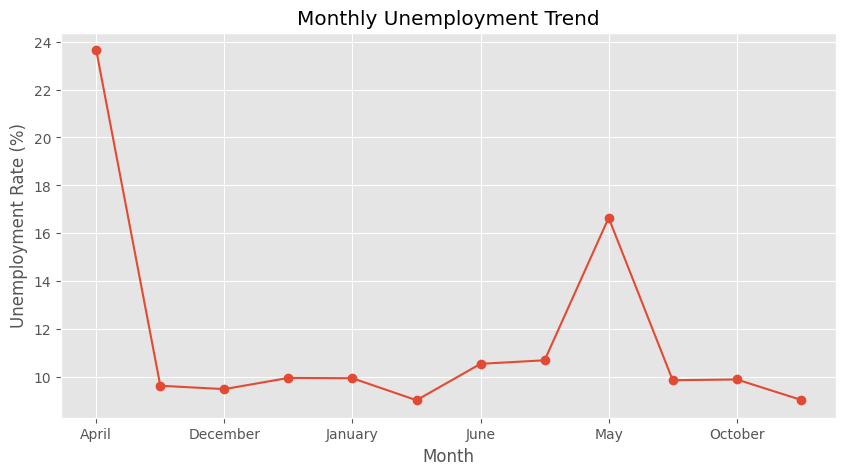

In [21]:
plt.figure(figsize=(10,5))

month_avg.plot(marker="o")

plt.title("Monthly Unemployment Trend")
plt.xlabel("Month")
plt.ylabel("Unemployment Rate (%)")

plt.show()

## Observation

- Unemployment changes across months.
- Some months have noticeably higher unemployment rates.

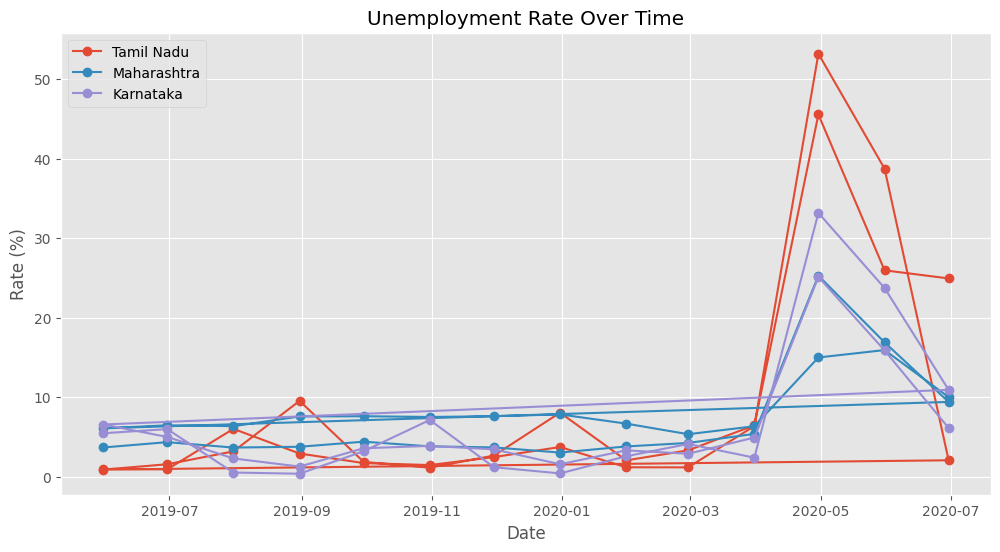

In [22]:
states = ["Tamil Nadu", "Maharashtra", "Karnataka"]

plt.figure(figsize=(12,6))

for state in states:
    temp = df[df["Region"] == state]
    plt.plot(
        temp["Date"],
        temp["Estimated Unemployment Rate (%)"],
        marker="o",
        label=state
    )

plt.legend()
plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Rate (%)")

plt.show()

## Observation

- The unemployment trend differs across the selected states.
- Some states show sudden spikes during certain months.

In [23]:
top10 = df.groupby("Region")["Estimated Unemployment Rate (%)"]\
.mean()\
.sort_values(ascending=False)\
.head(10)

top10

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64

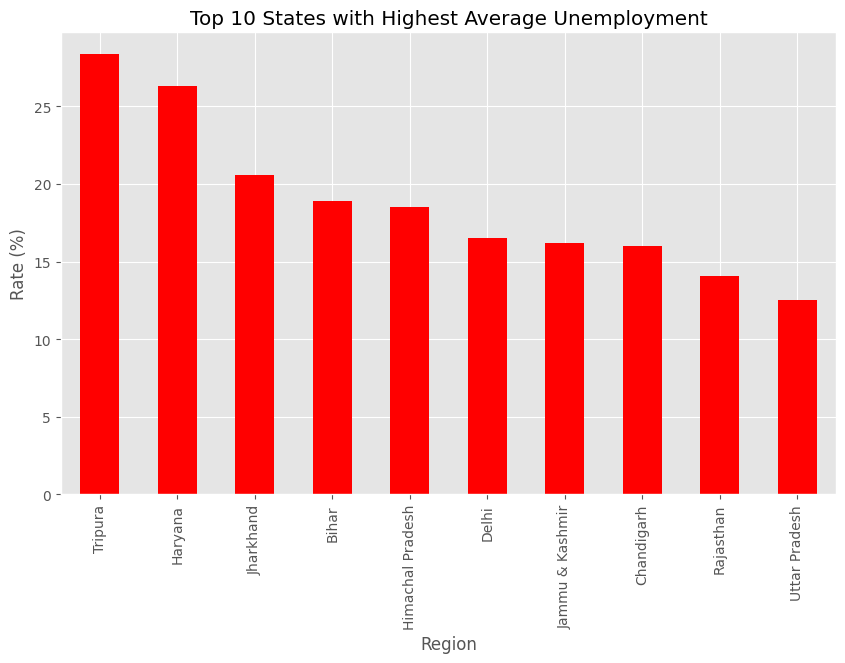

In [24]:
plt.figure(figsize=(10,6))

top10.plot(kind="bar", color="red")

plt.title("Top 10 States with Highest Average Unemployment")
plt.ylabel("Rate (%)")

plt.show()

## Observation

- These are the top 10 regions with the highest average unemployment rates.
- The differences between the regions are clearly visible.

In [25]:
corr = df[
[
"Estimated Unemployment Rate (%)",
"Estimated Employed",
"Estimated Labour Participation Rate (%)"
]
].corr()

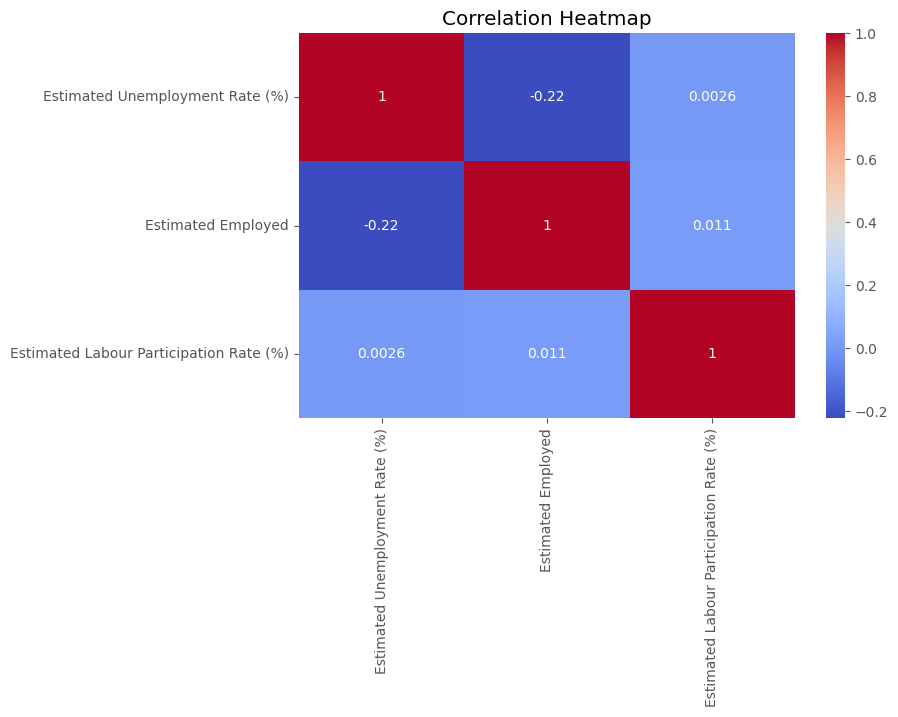

In [26]:
plt.figure(figsize=(8,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

## Observation

- The heatmap shows the relationship between unemployment, employment, and labour participation.
- Stronger positive or negative values indicate stronger correlations.

In [27]:
pre = df[df["Date"] < "2020-03-01"]

post = df[df["Date"] >= "2020-03-01"]

In [28]:
pre_avg = pre["Estimated Unemployment Rate (%)"].mean()

post_avg = post["Estimated Unemployment Rate (%)"].mean()

print(pre_avg)

print(post_avg)

9.509533582089553
17.774362745098042


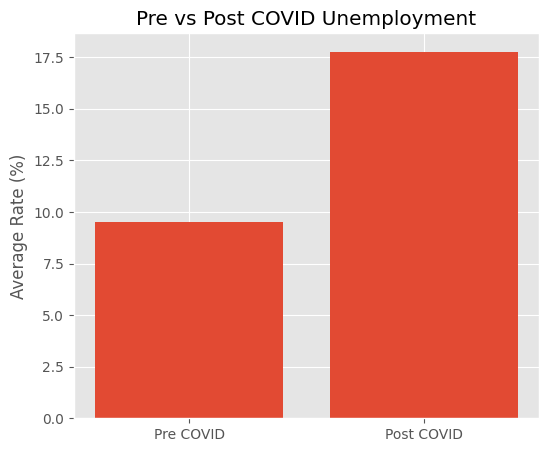

In [29]:
plt.figure(figsize=(6,5))

plt.bar(
    ["Pre COVID", "Post COVID"],
    [pre_avg, post_avg]
)

plt.title("Pre vs Post COVID Unemployment")

plt.ylabel("Average Rate (%)")

plt.show()

## Observation

- The average unemployment rate increased after March 2020.
- This reflects the impact of the COVID-19 pandemic on employment.

# Conclusion

- The unemployment rate differs significantly across Indian regions.
- Monthly trends show fluctuations in unemployment.
- Some states experienced higher unemployment than others.
- The correlation analysis highlights relationships between unemployment, employment, and labour participation.
- The comparison between pre-COVID and post-COVID periods shows that unemployment increased after the pandemic.